In [1]:
import sys
import os
import importlib

#--------------------------------------------------------------
# clearing cache so that the core.py is called from the right place, had issue earlier
modules_to_clear = [
    m for m in sys.modules.keys() 
    if any(p in m for p in ["models", "src", "data", "metrics"])
]
for module in modules_to_clear:
    del sys.modules[module]
PROJECT_ROOT = "/Users/darya/Desktop/Diploma/COMPAS - criminals/whole_process"
sys.path = [p for p in sys.path if "COMPAS - criminals" not in p]
sys.path.insert(0, PROJECT_ROOT)
cox_upd_path = os.path.join(PROJECT_ROOT, "models", "cox_model_upd.py")
spec = importlib.util.spec_from_file_location("cox_model_upd", cox_upd_path)
cox_model_upd = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cox_model_upd)
CoxModelUpd = cox_model_upd.CoxModelUpd
#issue with the ibs_metric part because of numba, i beleive this helped fix it
os.environ["NUMBA_DISABLE_JIT"] = "1"
#--------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#from data.data_processor import DataProcessor
from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from models.cox_model import CoxModel
from models.cox_model_upd import CoxModelUpd
from metrics.ibs import IBSMetric
from metrics.ibs_remain import IBSRemainMetric
from metrics.auprc import AUPRCMetric
from metrics.recurrent_count_error import RecurrentCountError
from pipeline.evaluator import SurvivalEvaluator
from survivors.constants import get_y

In [2]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
print(df.columns)

Index(['name', 'age', 'sex', 'race', 'c_charge_degree', 'c_charge_desc',
       'in_custody', 'out_custody', 'custody_num', 'time_to_last_custody',
       'time_since_last_arrest', 'time_to_future_arrest', 'event',
       'event_of_future_arrest', 'curr_dur_custody', 'sum_dur_custody',
       'average_dur_custody', 'all_future_arrest_times', 'all_future_events'],
      dtype='object')


In [3]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df.head(30)

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,curr_dur_custody
0,aajah herrington,1,0,385,0,23,384.0,1.00,23.0
1,aaron aprile,1,0,55,0,27,0.0,55.00,510.0
2,aaron davis,1,0,432,0,41,314.0,118.00,8.0
3,aaron eddins,1,0,104,0,37,104.0,0.00,32.0
4,aaron epstein,1,0,297,1,22,296.0,1.00,1.0
5,aaron epstein,2,297,357,1,22,59.0,1.00,50.0
6,aaron epstein,3,357,430,0,22,23.0,17.33,10.0
7,aaron evans,1,0,95,1,26,94.0,1.00,0.0
8,aaron evans,2,95,318,1,26,223.0,0.50,1.0
9,aaron evans,3,318,425,0,26,106.0,0.67,14.0


In [4]:
'''# importlib.reload(data.data_processor)

processor = DataProcessor("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df = pd.get_dummies(
    cox_df,
    columns=["sex", "race"],
    drop_first=True
)
cox_df.head(20)'''

'# importlib.reload(data.data_processor)\n\nprocessor = DataProcessor("data/individual_custody_timeline_rfm.csv")\ncox_df = processor.load_and_prepare()\ncox_df = pd.get_dummies(\n    cox_df,\n    columns=["sex", "race"],\n    drop_first=True\n)\ncox_df.head(20)'

Data split into train and test data

In [5]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [6]:
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

train_cens = train_df["event"].astype(bool)
test_cens = test_df["event"].astype(bool)

survival_train = get_y(
    cens=train_cens,
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)

In [7]:
train_df.query("name=='daniel diaz'")

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
1171,daniel diaz,1,0,104,1,50,70.0,34.00,104
1172,daniel diaz,2,104,159,1,50,24.0,32.50,55
1173,daniel diaz,3,159,235,1,50,12.0,43.00,76
1174,daniel diaz,4,235,261,1,50,25.0,32.50,26
1175,daniel diaz,5,261,391,1,50,12.0,49.60,130
1176,daniel diaz,6,391,1079,1,50,509.0,71.17,688
1177,daniel diaz,7,1079,1088,1,50,7.0,61.29,9
1178,daniel diaz,8,1088,1128,0,50,6.0,57.88,40


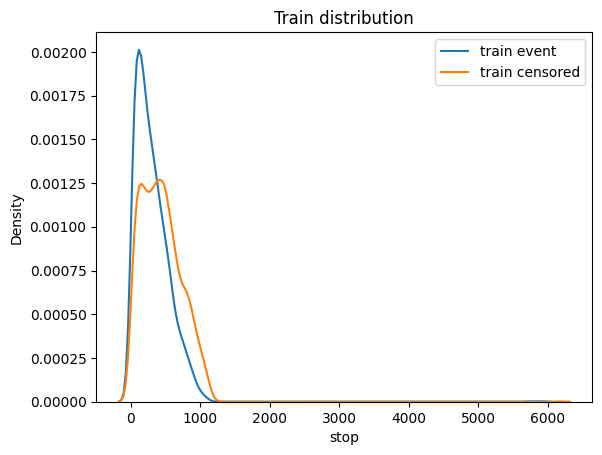

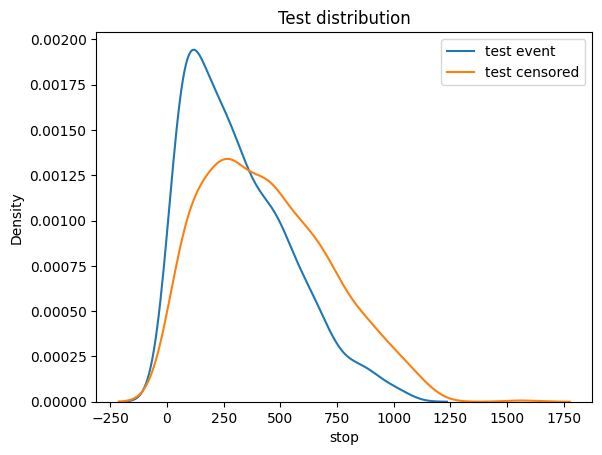

Train events: event
0    3382
1    2767
Name: count, dtype: int64
Test events: event
0    845
1    778
Name: count, dtype: int64


In [8]:
plt.figure()
sns.kdeplot(train_df[train_df["event"]==1]["stop"], label="train event")
sns.kdeplot(train_df[train_df["event"]==0]["stop"], label="train censored")
plt.legend()
plt.title("Train distribution")
plt.show()

plt.figure()
sns.kdeplot(test_df[test_df["event"]==1]["stop"], label="test event")
sns.kdeplot(test_df[test_df["event"]==0]["stop"], label="test censored")
plt.legend()
plt.title("Test distribution")
plt.show()

print("Train events:", train_df["event"].value_counts())
print("Test events:", test_df["event"].value_counts())


Using the original CoxModel file that I had (cox_model.py)

In [9]:
# importlib.reload(models.cox_model)
features = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop", "episode_col"]]

cols_for_model = ["name", "start", "stop", "event"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

invalid_mask = train_model_df["start"] >= train_model_df["stop"]
eps = 1e-6
train_model_df.loc[invalid_mask, "stop"] = train_model_df.loc[invalid_mask, "stop"] + eps

model = CoxModel(features=features)
model.fit(train_model_df)

/var/folders/2p/qsm8n7490mjg4yr9_fxk_wkc0000gn/T/ipykernel_11010/1231343058.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[213.000001 286.000001]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_model_df.loc[invalid_mask, "stop"] = train_model_df.loc[invalid_mask, "stop"] + eps


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-19047.60
time fit was run,2026-03-06 08:28:21 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [10]:
train_model_df.query("name=='aaron epstein'")

,name,start,stop,event,age,time_since_last_arrest,average_dur_custody
4,aaron epstein,0,297.0,1,22,296.0,1.00
5,aaron epstein,297,357.0,1,22,59.0,1.00
6,aaron epstein,357,430.0,0,22,23.0,17.33


In [11]:
train_model_df["time_since_last_arrest"].value_counts()

time_since_last_arrest
 0.0       338
 21.0       34
 25.0       33
 20.0       32
 19.0       32
          ... 
-42.0        1
 1066.0      1
 665.0       1
 868.0       1
 584.0       1
Name: count, Length: 880, dtype: int64

In [12]:
train_model_df

,name,start,stop,event,age,time_since_last_arrest,average_dur_custody
0,aajah herrington,0,385.0,0,23,384.0,1.0
1,aaron aprile,0,55.0,0,27,0.0,55.0
2,aaron davis,0,432.0,0,41,314.0,118.0
3,aaron eddins,0,104.0,0,37,104.0,0.0
4,aaron epstein,0,297.0,1,22,296.0,1.0
...,...,...,...,...,...,...,...
6144,zavier harris,0,302.0,0,20,0.0,302.0
6145,zaysha clark,0,430.0,0,24,429.0,1.0
6146,zechariah faulk,0,69.0,0,28,69.0,0.0
6147,zeke zikria,0,152.0,0,46,150.0,2.0


In [13]:
train_df["stop"].describe()

count    6149.000000
mean      381.495853
std       289.923100
min         1.000000
25%       159.000000
50%       336.000000
75%       547.000000
max      6141.000000
Name: stop, dtype: float64

In [14]:
survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)

In [15]:
test_df

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0,699,0,25,688.0,11.0,699
1,aaron villacampa,1,0,107,0,26,106.0,1.0,107
2,abraham ballestas,1,0,35,0,52,34.0,1.0,35
3,acie canteen,1,0,215,0,27,214.0,1.0,215
4,adam gillstrap,1,0,630,0,35,628.0,2.0,630
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0,34,0,28,33.0,1.0,34
1619,zachary whalen,1,0,634,0,24,632.0,2.0,634
1620,zaheer khan,1,0,184,0,26,183.0,1.0,184
1621,zhivago walker,1,0,126,0,30,125.0,1.0,126


In [16]:
from lifelines.utils import concordance_index
#times = np.linspace(0, train_df["stop"].max(), 200)
horizon = np.quantile(train_model_df["stop"], 0.95)
times = np.linspace(0, horizon, 200)

test_features = test_df[features].copy()
predictions = model.predict_survival(test_features, times)
#predictions = model.predict_survival(test_df, times)
estimate = predictions.values
estimate = np.asarray(estimate, dtype=np.float64)
times = np.asarray(times, dtype=np.float64)

survival_train = survival_train.astype([("event", "?"), ("time", "f8")])
survival_test = survival_test.astype([("event", "?"), ("time", "f8")])

print(survival_test.dtype.names)
ibs_metric = IBSMetric()
mean_ibs, ibs_by_time = ibs_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)

print(mean_ibs)

survival_train_cens = survival_train.astype([("cens", "?"), ("time", "f8")])
survival_test_cens = survival_test.astype([("cens", "?"), ("time", "f8")])

auprc_metric = AUPRCMetric()
auprc = auprc_metric.compute(
    survival_train_cens,
    survival_test_cens,
    estimate,
    times
)
print("AUPRC:", np.mean(auprc))

ci_metric = concordance_index(
    test_df["stop"],
    np.trapz(predictions.values, times, axis=1),
    test_cens
)
print("Concordance Index:", ci_metric)

('event', 'time')
0.18747794690263048
AUPRC: 0.6221815010837322
Concordance Index: 0.743693834741477


In [17]:
predictions

,0.000000,4.432161,8.864322,13.296482,17.728643,22.160804,26.592965,31.025126,35.457286,39.889447,...,842.110553,846.542714,850.974874,855.407035,859.839196,864.271357,868.703518,873.135678,877.567839,882.000000
0,1.0,0.999978,0.999863,0.999776,0.999696,0.999558,0.999471,0.999332,0.999198,0.999031,...,0.949900,0.949551,0.949487,0.949193,0.948665,0.948236,0.947956,0.947608,0.946856,0.946042
1,1.0,0.998910,0.993127,0.988746,0.984787,0.977950,0.973669,0.966852,0.960317,0.952264,...,0.074800,0.073425,0.073177,0.072040,0.070046,0.068466,0.067456,0.066215,0.063617,0.060917
2,1.0,0.998377,0.989782,0.983286,0.977430,0.967341,0.961042,0.951039,0.941481,0.929749,...,0.021039,0.020465,0.020362,0.019893,0.019079,0.018441,0.018038,0.017546,0.016530,0.015497
3,1.0,0.999462,0.996602,0.994430,0.992463,0.989056,0.986917,0.983501,0.980214,0.976149,...,0.278122,0.275585,0.275125,0.273009,0.269252,0.266236,0.264291,0.261881,0.256758,0.251321
4,1.0,0.999965,0.999778,0.999636,0.999507,0.999284,0.999143,0.998917,0.998700,0.998429,...,0.920049,0.919500,0.919400,0.918938,0.918109,0.917436,0.916998,0.916452,0.915273,0.913999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,1.0,0.998257,0.989025,0.982053,0.975770,0.964953,0.958204,0.947492,0.937265,0.924721,...,0.015783,0.015321,0.015238,0.014861,0.014209,0.013699,0.013377,0.012986,0.012180,0.011364
1619,1.0,0.999965,0.999778,0.999635,0.999506,0.999281,0.999140,0.998913,0.998695,0.998423,...,0.919752,0.919201,0.919101,0.918637,0.917805,0.917130,0.916690,0.916142,0.914959,0.913680
1620,1.0,0.999340,0.995832,0.993169,0.990759,0.986588,0.983970,0.979792,0.975776,0.970813,...,0.207985,0.205660,0.205239,0.203303,0.199876,0.197133,0.195367,0.193183,0.188556,0.183668
1621,1.0,0.999047,0.993990,0.990156,0.986691,0.980700,0.976948,0.970967,0.965227,0.958150,...,0.103694,0.102025,0.101724,0.100342,0.097910,0.095976,0.094738,0.093213,0.090008,0.086660


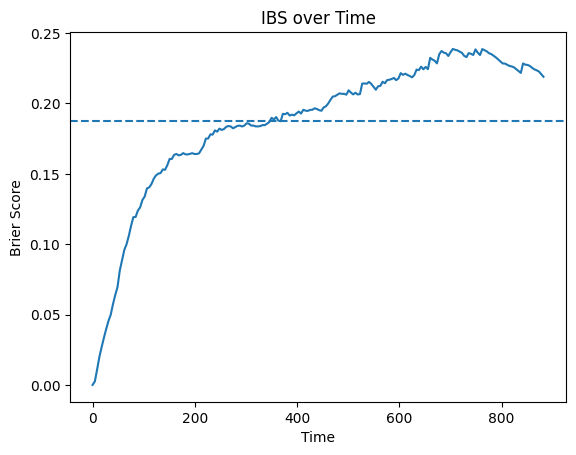

In [18]:
plt.plot(times, ibs_by_time)
plt.axhline(y=mean_ibs, linestyle="--")
plt.title("IBS over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.show()

In [19]:
from survivors import metrics
test_df_results = test_df[["name", "episode_col", "stop", "event"]].copy()

test_df_results["stop"] = test_df["stop"] - test_df["start"]

test_df_results["ibs"] = metrics.ibs(
            survival_train=survival_train,
            survival_test=survival_test,
            estimate=estimate,
            times=times,
            axis=0
        )
test_df_results["auprc"] = metrics.auprc(
            survival_train=survival_train_cens,
            survival_test=survival_test_cens,
            estimate=estimate,
            times=times,
            axis=0
        )

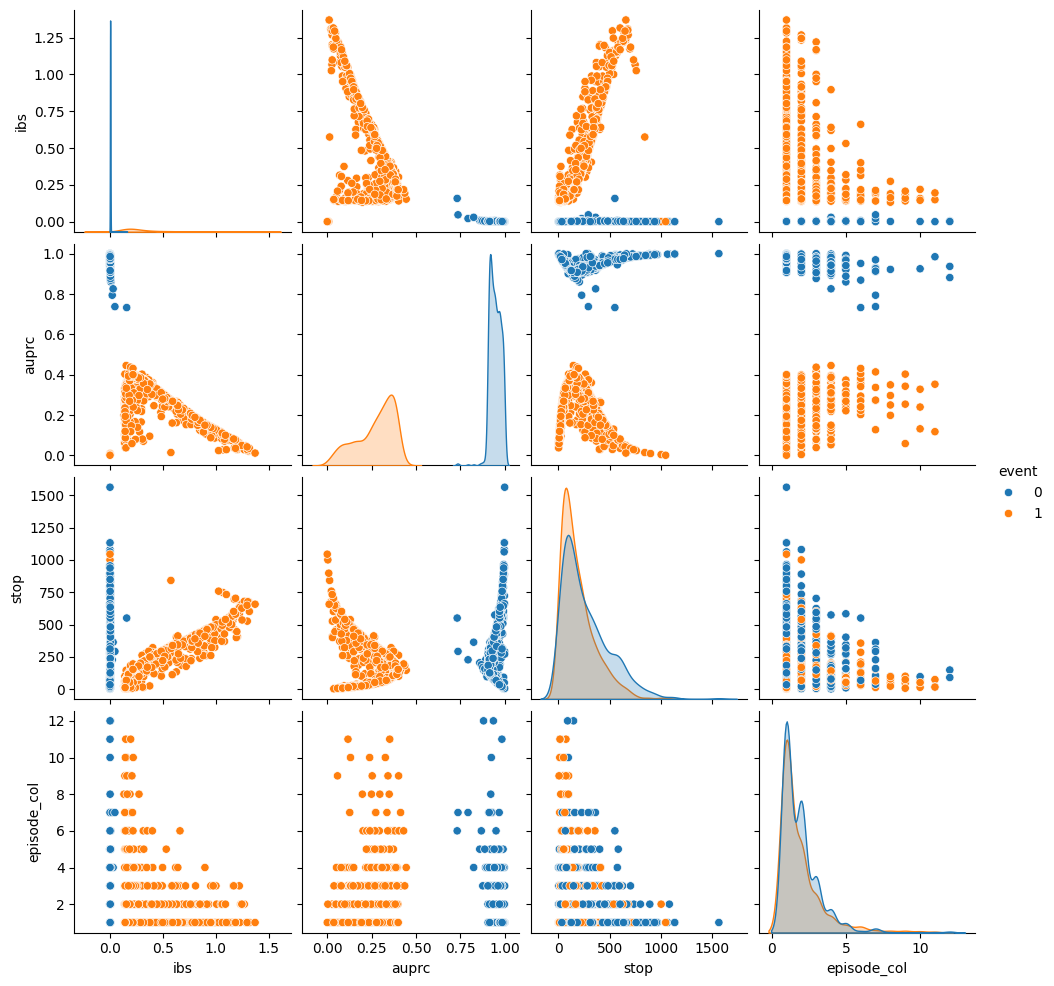

In [20]:
# sns.scatterplot(x="episode_col", y="auprc", data=test_df_results)
sns.pairplot(test_df_results, vars=["ibs", "auprc", "stop", "episode_col"], hue="event")

In [21]:
test_df_results[test_df_results["episode_col"] >= 8].round(3)
# test_df["dur"].describe()

,name,episode_col,stop,event,ibs,auprc
216,brandon ross,8,47,1,0.189,0.249
217,brandon ross,9,47,1,0.184,0.253
218,brandon ross,10,67,1,0.157,0.327
219,brandon ross,11,74,1,0.149,0.352
220,brandon ross,12,148,0,0.004,0.881
592,eric redmond,8,23,1,0.132,0.198
593,eric redmond,9,100,1,0.141,0.402
594,eric redmond,10,14,1,0.145,0.131
595,eric redmond,11,18,0,0.000,0.984
770,jason jaigobin,8,99,0,0.001,0.922


<Axes: xlabel='episode_col', ylabel='ibs'>

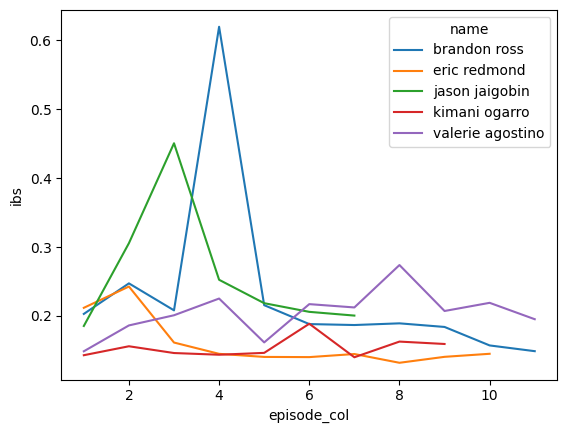

In [22]:
freq_name = test_df_results.query("episode_col >= 8")["name"].unique()
sns.lineplot(x="episode_col", y="ibs", hue="name",
                data=test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)"))

<Axes: xlabel='episode_col'>

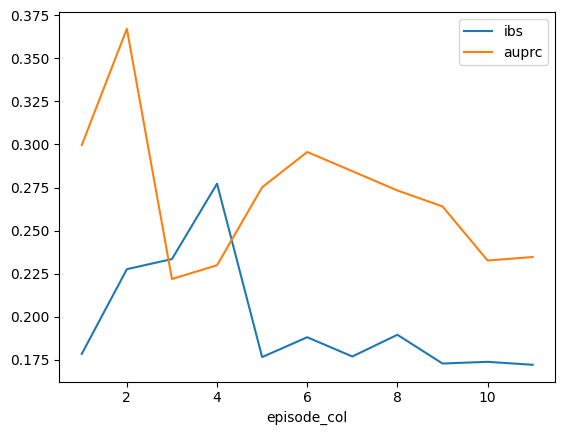

In [23]:
test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)").groupby("episode_col")[["ibs", "auprc"]].mean().plot()

In [24]:
# tr_pred = 1 - model.predict_survival(train_df, times).values.T
tr_pred = model.predict_cumulative_hazard(train_df, times)
tr_max = np.quantile(tr_pred.max(), 0.95)

# pred = 1 - model.predict_survival(test_df, times).values.T
# test_df.drop_duplicates(["name"], keep='first')
pred = model.predict_cumulative_hazard(test_df, times)
# pred[:] = train_df.groupby("name")["event"].sum().mean()
print("pred shape:", pred.shape)
print("len(test_df):", len(test_df))
metric = RecurrentCountError()

recurrent_error = metric.compute(
    survival_train=None,
    survival_test=test_df,
    estimate=pred / tr_max,
    times=times
)

mean_events = test_df.groupby("name")["event"].sum().mean()
print("Mean event =", mean_events)
print("Integrated cumulative event error:", recurrent_error)

pred shape: (200, 1623)
len(test_df): 1623
Mean event = 0.9207100591715977
Integrated cumulative event error: 0.9534877334386863


In [25]:
pred

,0,1,2,3,4,5,6,7,8,9,...,1613,1614,1615,1616,1617,1618,1619,1620,1621,1622
0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4.432161,0.000022,0.001091,0.001624,0.000538,0.000035,0.000148,0.002107,0.000375,0.000970,0.001042,...,0.000045,0.002019,0.000043,0.000052,0.000008,0.001745,0.000035,0.000660,0.000953,0.000016
8.864322,0.000137,0.006897,0.010271,0.003404,0.000222,0.000934,0.013322,0.002374,0.006131,0.006590,...,0.000287,0.012770,0.000275,0.000326,0.000052,0.011035,0.000223,0.004177,0.006028,0.000101
13.296482,0.000224,0.011318,0.016855,0.005586,0.000364,0.001533,0.021862,0.003895,0.010062,0.010815,...,0.000471,0.020957,0.000451,0.000536,0.000086,0.018110,0.000365,0.006854,0.009893,0.000166
17.728643,0.000304,0.015329,0.022829,0.007566,0.000493,0.002076,0.029610,0.005276,0.013628,0.014648,...,0.000638,0.028384,0.000611,0.000725,0.000116,0.024528,0.000495,0.009284,0.013398,0.000225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864.271357,0.053152,2.681424,3.993172,1.323371,0.086172,0.363214,5.179449,0.922840,2.383745,2.562176,...,0.111637,4.964932,0.106948,0.126871,0.020332,4.290421,0.086506,1.623878,2.343658,0.039302
868.703518,0.053447,2.696282,4.015298,1.330703,0.086650,0.365227,5.208148,0.927953,2.396953,2.576372,...,0.112256,4.992442,0.107540,0.127574,0.020445,4.314194,0.086985,1.632876,2.356644,0.039520
873.135678,0.053815,2.714842,4.042938,1.339864,0.087246,0.367741,5.243999,0.934341,2.413453,2.594107,...,0.113029,5.026809,0.108280,0.128452,0.020586,4.343891,0.087584,1.644116,2.372866,0.039792
877.567839,0.054608,2.754879,4.102561,1.359623,0.088533,0.373164,5.321334,0.948120,2.449045,2.632364,...,0.114695,5.100941,0.109877,0.130346,0.020889,4.407952,0.088876,1.668363,2.407860,0.040379


In [26]:
test_df.drop_duplicates(["name"], keep='first')

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0,699,0,25,688.0,11.0,699
1,aaron villacampa,1,0,107,0,26,106.0,1.0,107
2,abraham ballestas,1,0,35,0,52,34.0,1.0,35
3,acie canteen,1,0,215,0,27,214.0,1.0,215
4,adam gillstrap,1,0,630,0,35,628.0,2.0,630
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0,34,0,28,33.0,1.0,34
1619,zachary whalen,1,0,634,0,24,632.0,2.0,634
1620,zaheer khan,1,0,184,0,26,183.0,1.0,184
1621,zhivago walker,1,0,126,0,30,125.0,1.0,126


Using the updated CoxModelUpd file (cox_model_upd.py). RECURRENT WITH EPISODE_COL case

In [27]:
# RECURRENT WITH EPISODE_COL
features1 = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop"]]

cols_for_model1 = ["name", "episode_col", "start", "stop", "event"] + \
                 [c for c in features1 if c != "episode_col"]

train_model_df1 = train_df[cols_for_model1].copy().fillna(-1)


invalid_mask = train_model_df1["start"] >= train_model_df1["stop"]
train_model_df1.loc[invalid_mask, "stop"] = train_model_df1.loc[invalid_mask, "stop"] + eps

model1 = CoxModelUpd(
    features=[c for c in features1 if c != "episode_col"],
    mode="recurrent",
    use_episode=True
)

model1.fit(train_model_df1)


/var/folders/2p/qsm8n7490mjg4yr9_fxk_wkc0000gn/T/ipykernel_11010/3745801417.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[213.000001 286.000001]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_model_df1.loc[invalid_mask, "stop"] = train_model_df1.loc[invalid_mask, "stop"] + eps


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-15242.40


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [28]:
from lifelines.utils import concordance_index
#times = np.linspace(0, train_df["dur"].max(), 200)
train_dur1 = train_model_df1["stop"]
horizon1 = np.quantile(train_dur1, 0.95)
times1 = np.linspace(0, horizon1, 200)

test_model_df1 = test_df[cols_for_model1].copy().fillna(-1)

print("Train episodes:", sorted(train_model_df1["episode_col"].unique()))
print("Test episodes:", sorted(test_model_df1["episode_col"].unique()))

# had an issue with strata, so removing unseen strata
valid_episodes = train_model_df1["episode_col"].unique()
test_model_df1 = test_model_df1[
    test_model_df1["episode_col"].isin(valid_episodes)
]


predictions1 = model1.predict_survival(test_model_df1, times1)
#predictions = model.predict_survival(test_df, times)
estimate1 = predictions1.values.astype(np.float64)
times1 = np.asarray(times1, dtype=np.float64)

test_dur1 = test_model_df1["stop"]

survival_test1 = np.array(
    list(zip(
        test_model_df1["event"].astype(bool),
        test_dur1.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

survival_train1 = np.array(
    list(zip(
        train_model_df1["event"].astype(bool),
        train_dur1.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)
print(survival_test1.dtype.names)


ibs_metric1 = IBSMetric()
mean_ibs1, ibs_by_time1 = ibs_metric.compute(
    survival_train1,
    survival_test1,
    estimate1,
    times1
)

print("IBS:", mean_ibs1)

survival_test_cens1 = np.array(
    list(zip(
        (~test_model_df1["event"].astype(bool)),
        test_dur1.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

survival_train_cens1 = np.array(
    list(zip(
        (~train_model_df1["event"].astype(bool)),
        train_dur1.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

auprc_metric1 = AUPRCMetric()
auprc1 = auprc_metric1.compute(
    survival_train_cens1,
    survival_test_cens1,
    estimate1,
    times1
)
print("AUPRC:", np.mean(auprc1))

ci_metric1 = concordance_index(
    test_dur1,
    np.trapz(predictions1.values, times1, axis=1),
    test_model_df1["event"]
)
print("Concordance Index:", ci_metric1)

Train episodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Test episodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
('event', 'time')
IBS: 0.3250904706322034
AUPRC: 0.5682633346469907
Concordance Index: 0.5089647206997344


Using the updated CoxModelUpd file (cox_model_upd.py). RECURRENT WITHOUT EPISODE_COL case

In [29]:
# RECURRENT WITHOUT EPISODE_COL
features2 = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop", "episode_col"]]

cols_for_model2 = ["name", "start", "stop", "event"] + features
train_model_df2 = train_df[cols_for_model2].copy().fillna(-1)


invalid_mask = train_model_df2["start"] >= train_model_df2["stop"]
train_model_df2.loc[invalid_mask, "stop"] = train_model_df2.loc[invalid_mask, "stop"] + eps

model2 = CoxModelUpd(
    features=features2,
    mode="recurrent",
    use_episode=False
)
model2.fit(train_model_df2)

/var/folders/2p/qsm8n7490mjg4yr9_fxk_wkc0000gn/T/ipykernel_11010/2025950861.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[213.000001 286.000001]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_model_df2.loc[invalid_mask, "stop"] = train_model_df2.loc[invalid_mask, "stop"] + eps


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-19047.60
time fit was run,2026-03-06 08:28:26 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [30]:
train_model_df2["event"].value_counts()

event
0    3382
1    2767
Name: count, dtype: int64

In [31]:
from lifelines.utils import concordance_index

train_dur2 = train_model_df2["stop"]
horizon2 = np.quantile(train_dur2, 0.95)
times2 = np.linspace(0, horizon2, 200)
times2 = np.asarray(times2, dtype=np.float64)

test_model_df2 = test_df[cols_for_model2].copy().fillna(-1)

# reording to avoid issues
test_model_df2 = test_model_df2.reset_index(drop=True)

predictions2 = model2.predict_survival(test_model_df2, times2)
estimate2 = predictions2.values.astype(np.float64)

test_dur2 = test_model_df2["stop"]
train_dur2 = train_model_df2["stop"]

survival_test2 = np.array(
    list(zip(
        test_model_df2["event"].astype(bool),
        test_dur2.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

survival_train2 = np.array(
    list(zip(
        train_model_df2["event"].astype(bool),
        train_dur2.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

ibs_metric2 = IBSMetric()
mean_ibs2, ibs_by_time2 = ibs_metric2.compute(
    survival_train2,
    survival_test2,
    estimate2,
    times2
)
print("IBS:", mean_ibs2)

survival_test_cens2 = np.array(
    list(zip(
        ~test_model_df2["event"].astype(bool),
        test_dur2.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

survival_train_cens2 = np.array(
    list(zip(
        ~train_model_df2["event"].astype(bool),
        train_dur2.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

auprc_metric2 = AUPRCMetric()
auprc2 = auprc_metric2.compute(
    survival_train_cens2,
    survival_test_cens2,
    estimate2,
    times2
)
print("AUPRC:", np.mean(auprc2))

ci_metric2 = concordance_index(
    test_dur2,
    np.trapz(estimate2, times2, axis=1),
    test_model_df2["event"]
)
print("Concordance Index:", ci_metric2)

IBS: 0.18922884837725978
AUPRC: 0.5635089368817466
Concordance Index: 0.743693834741477


In [32]:
train_model_df2

,name,start,stop,event,age,time_since_last_arrest,average_dur_custody
0,aajah herrington,0,385.0,0,23,384.0,1.0
1,aaron aprile,0,55.0,0,27,0.0,55.0
2,aaron davis,0,432.0,0,41,314.0,118.0
3,aaron eddins,0,104.0,0,37,104.0,0.0
4,aaron epstein,0,297.0,1,22,296.0,1.0
...,...,...,...,...,...,...,...
6144,zavier harris,0,302.0,0,20,0.0,302.0
6145,zaysha clark,0,430.0,0,24,429.0,1.0
6146,zechariah faulk,0,69.0,0,28,69.0,0.0
6147,zeke zikria,0,152.0,0,46,150.0,2.0


Using the updated CoxModelUpd file (cox_model_upd.py). INDEPENDENT case

In [33]:
# INDEPENDENT
train_ind = train_df.copy() #.drop_duplicates("name").copy()
#train_ind["duration"] = train_ind["stop"] - train_ind["start"]

features3 = [c for c in train_ind.columns 
            if c not in ["name", "start", "time", "event", "stop", "episode_col"]]

cols_for_model3 = ["time", "event"] + features3
train_model_df3 = train_ind[cols_for_model3].copy().fillna(-1)

model3 = CoxModelUpd(
    features=features3,
    mode="independent",
    penalizer=0.0001
)

model3.fit(train_model_df3)

<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.0001
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -18455.82
         time fit was run = 2026-03-06 08:28:27 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
time_since_last_arrest -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
average_dur_custody    -0.05      0.95      0.00           -0.05           -0.05                0.95                0.95

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -0.94   0.35      1.53
time_since_last_arrest    0.00 -58.11 <0.005       inf
average_dur_custody       0.00 -50.96 <0.005       inf
---
Concordance = 0.93
Partial AIC = 36917.65
log-likelihood ratio test = 7139.18 on 3 df
-log2(p) of ll-ratio test = inf

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [34]:
train_ind

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
0,aajah herrington,1,0,385,0,23,384.0,1.0,385
1,aaron aprile,1,0,55,0,27,0.0,55.0,55
2,aaron davis,1,0,432,0,41,314.0,118.0,432
3,aaron eddins,1,0,104,0,37,104.0,0.0,104
4,aaron epstein,1,0,297,1,22,296.0,1.0,297
...,...,...,...,...,...,...,...,...,...
6144,zavier harris,1,0,302,0,20,0.0,302.0,302
6145,zaysha clark,1,0,430,0,24,429.0,1.0,430
6146,zechariah faulk,1,0,69,0,28,69.0,0.0,69
6147,zeke zikria,1,0,152,0,46,150.0,2.0,152


In [35]:
from lifelines.utils import concordance_index

# doing one row per individual
test_ind = test_df.drop_duplicates("name").copy()

# duration = time - entry
#test_ind["duration"] = test_ind["time"] - test_ind["start"]

test_model_df3 = test_ind[cols_for_model3].copy()
test_model_df3 = test_model_df3.reset_index(drop=True).fillna(-1)

train_dur3 = train_model_df3["time"]
horizon3 = np.quantile(train_dur3, 0.95)

times3 = np.linspace(0, horizon3, 200)
times3 = np.asarray(times3, dtype=np.float64)

predictions3 = model3.predict_survival(test_model_df3.drop(["time", "event"], axis=1, inplace=False), times3)
estimate3 = predictions3.values.astype(np.float64)

test_dur3 = test_model_df3["time"]
train_dur3 = train_model_df3["time"]

survival_test3 = np.array(
    list(zip(
        test_model_df3["event"].astype(bool),
        test_dur3.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

survival_train3 = np.array(
    list(zip(
        train_model_df3["event"].astype(bool),
        train_dur3.astype(float)
    )),
    dtype=[("event", "?"), ("time", "f8")]
)

ibs_metric3 = IBSMetric()
mean_ibs3, ibs_by_time3 = ibs_metric3.compute(
    survival_train3,
    survival_test3,
    estimate3,
    times3
)
print("IBS:", mean_ibs3)

survival_test_cens3 = np.array(
    list(zip(
        ~test_model_df3["event"].astype(bool),
        test_dur3.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

survival_train_cens3 = np.array(
    list(zip(
        ~train_model_df3["event"].astype(bool),
        train_dur3.astype(float)
    )),
    dtype=[("cens", "?"), ("time", "f8")]
)

auprc_metric3 = AUPRCMetric()
auprc3 = auprc_metric3.compute(
    survival_train_cens3,
    survival_test_cens3,
    estimate3,
    times3
)
print("AUPRC:", np.mean(auprc3))

ci_metric3 = concordance_index(
    test_dur3,
    np.trapz(estimate3, times3, axis=1),
    test_model_df3["event"]
)
print("Concordance Index:", ci_metric3)

IBS: 0.05123845639324076
AUPRC: 0.7720888824325957
Concordance Index: 0.9448302579849055


In [36]:
test_ind

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0,699,0,25,688.0,11.0,699
1,aaron villacampa,1,0,107,0,26,106.0,1.0,107
2,abraham ballestas,1,0,35,0,52,34.0,1.0,35
3,acie canteen,1,0,215,0,27,214.0,1.0,215
4,adam gillstrap,1,0,630,0,35,628.0,2.0,630
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0,34,0,28,33.0,1.0,34
1619,zachary whalen,1,0,634,0,24,632.0,2.0,634
1620,zaheer khan,1,0,184,0,26,183.0,1.0,184
1621,zhivago walker,1,0,126,0,30,125.0,1.0,126


In [37]:
train_ind.sort_values("start")

,name,episode_col,start,stop,event,age,time_since_last_arrest,average_dur_custody,time
0,aajah herrington,1,0,385,0,23,384.0,1.00,385
3462,kiyoshi tanaka-bustios,1,0,224,1,28,170.0,54.00,224
3464,koffi mcshine,1,0,185,0,35,147.0,38.00,185
3465,kollin whitaker,1,0,178,0,39,177.0,1.00,178
3466,korbin goodroad,1,0,481,0,20,480.0,1.00,481
...,...,...,...,...,...,...,...,...,...
1177,daniel diaz,7,1079,1088,1,50,7.0,61.29,9
1178,daniel diaz,8,1088,1128,0,50,6.0,57.88,40
812,celdrick rucker,2,1098,1107,0,28,0.0,159.00,9
2929,john walker,2,5723,5876,1,23,74.0,499.50,153


In [38]:
set(train_df["name"]) & set(test_df["name"])

set()

In [40]:
test_model_df3.drop(["time", "event"], axis=1, inplace=False)

,age,time_since_last_arrest,average_dur_custody
0,25,688.0,11.0
1,26,106.0,1.0
2,52,34.0,1.0
3,27,214.0,1.0
4,35,628.0,2.0
...,...,...,...
840,28,33.0,1.0
841,24,632.0,2.0
842,26,183.0,1.0
843,30,125.0,1.0


In [41]:
test_model_df3

,time,event,age,time_since_last_arrest,average_dur_custody
0,699,0,25,688.0,11.0
1,107,0,26,106.0,1.0
2,35,0,52,34.0,1.0
3,215,0,27,214.0,1.0
4,630,0,35,628.0,2.0
...,...,...,...,...,...
840,34,0,28,33.0,1.0
841,634,0,24,632.0,2.0
842,184,0,26,183.0,1.0
843,126,0,30,125.0,1.0


In [42]:
survival_test_cens3[0]

(True, 699.)

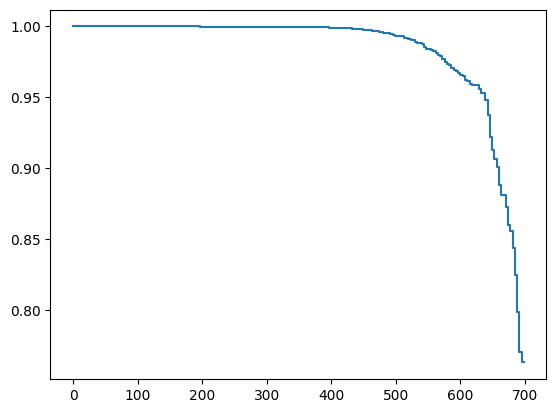

In [43]:
plt.step(times3, predictions3.iloc[0])